# 3.0 Data Preparation

Runs 3.1 â†’ 3.2 â†’ 3.3 â†’ 3.4 in sequence, with the real code and visuals used as evidence in the report.

## Setup

In [1]:
import sys, pathlib
sys.path.append(str(pathlib.Path.cwd().parent))
import matplotlib.pyplot as plt
import pandas as pd

from src.data_cleaning import load_raw, clean
from src.outlier_treatment import winsorize, compute_iqr_bounds, audit_iqr, remove_extreme_price_errors, PRICE_MAX_VALID
from src.data_transformation import transform, get_engineered_feature_lists, build_preprocessor
from src.final_dataset_output import build_prepared_dataset, RAW_CSV_PATH

# notebooks/ runs with a different cwd than the repo root â€” adjust the relative path
RAW_CSV_PATH = "../" + RAW_CSV_PATH

## 3.1 Data Selection
The excluded columns are dropped inside `clean()` below, per the decisions recorded in `src/config.py`. The data is selected based on previous data understanding studies

Below are some code to justify the report findings

In [2]:
df_raw = load_raw(RAW_CSV_PATH)

# currency check only have USD
is_only_usd = list(df_raw['currency'].unique()) == ['USD']
print(is_only_usd)

True


In [3]:
#shows the distribution of the category column in percentage and counts
print(df_raw['category'].value_counts(normalize=True) * 100)
print(df_raw['category'].value_counts())

category
housing/rent/apartment            99.938689
housing/rent/commercial/retail     0.042214
housing/rent                       0.007036
housing/rent/home                  0.004020
housing/rent/short_term            0.004020
housing/rent/condo                 0.003015
housing/rent/other                 0.001005
Name: proportion, dtype: float64
category
housing/rent/apartment            99431
housing/rent/commercial/retail       42
housing/rent                          7
housing/rent/home                     4
housing/rent/short_term               4
housing/rent/condo                    3
housing/rent/other                    1
Name: count, dtype: int64


In [4]:
#shows the distribution of the price_type column in percentage and counts
print(df_raw['price_type'].value_counts(normalize=True) * 100)
print(df_raw['price_type'].value_counts())

price_type
Monthly           99.995980
Weekly             0.003015
Monthly|Weekly     0.001005
Name: proportion, dtype: float64
price_type
Monthly           99488
Weekly                3
Monthly|Weekly        1
Name: count, dtype: int64


In [5]:
#shows the how many null percentage values in the address column
print(df_raw['address'].isnull().value_counts(normalize=True) * 100)

address
True     92.016444
False     7.983556
Name: proportion, dtype: float64


In [6]:
#shows the distribution of the fee column in percentage and counts
print(df_raw['fee'].value_counts(normalize=True) * 100)
print(df_raw['fee'].value_counts())

fee
No     99.797974
Yes     0.202026
Name: proportion, dtype: float64
fee
No     99291
Yes      201
Name: count, dtype: int64


## 3.2 Data Cleaning
As established in Section 2.3 (Findings 1â€“4) of the Data Understanding section, the raw file has 84 duplicate `id` values and several missing-value issues. This section applies the cleaning steps and shows the resulting counts as evidence.

In [7]:
df_raw = load_raw(RAW_CSV_PATH)
print('Raw shape:', df_raw.shape)
df_clean = clean(df_raw, verbose=True)

Raw shape: (99492, 22)
[3.2.1] Removed 84 duplicate listings (matched on id)
[3.2.2] Removed 65 non-standard-apartment / non-monthly rows
[3.2.3] Removed 483 rows with missing critical values

Final shape: (98860, 11)  (kept 99.4% of raw rows)
Missing values remaining:
 amenities       0
bathrooms       0
bedrooms        0
has_photo       0
pets_allowed    0
price           0
square_feet     0
cityname        0
state           0
latitude        0
longitude       0
dtype: int64


In [8]:
states = df_raw['state'].dropna().astype(str).str.strip()
print('All two-letter uppercase codes:', states.str.fullmatch(r'[A-Z]{2}').all())
print('Unique values:', states.nunique())

unique_states = sorted(states.unique())
top_5 = unique_states[:5]
remaining = len(unique_states) - len(top_5)
print(f"{top_5} (+ {remaining} more)")


All two-letter uppercase codes: True
Unique values: 51
['AK', 'AL', 'AR', 'AZ', 'CA'] (+ 46 more)


**Note on the duplicate check**: matching on `id` (not on the remaining columns) matters here. An earlier check that compared rows on every column *except* id/address flagged over 7,500 rows as 'duplicates' â€” but those had different `id`s and turned out to be legitimate separate listings (e.g. multiple identical units in the same apartment complex, same floor plan and rent). Only the 84 rows sharing an actual `id` were removed.

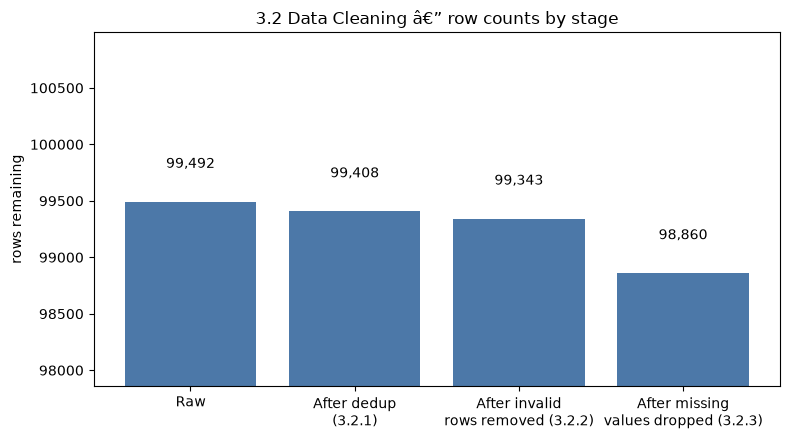

In [9]:
fig, ax = plt.subplots(figsize=(8,4.5))
stages = ['Raw', 'After dedup\n(3.2.1)', 'After invalid\nrows removed (3.2.2)', 'After missing\nvalues dropped (3.2.3)']
counts = [len(df_raw), len(df_raw)-84, len(df_raw)-84-65, len(df_clean)]
ax.bar(stages, counts, color='#4C78A8')
for i, c in enumerate(counts):
    ax.text(i, c+300, f'{c:,}', ha='center', fontsize=10)
ax.set_ylabel('rows remaining')
ax.set_title('3.2 Data Cleaning â€” row counts by stage')
ax.set_ylim(min(counts)-1000, max(counts)+1500)
fig.tight_layout()
fig.savefig('../outputs/figures/32_cleaning_stages.png', dpi=120)
plt.show()

## 3.3 Outlier Treatment
We inspect IQR bounds for price, square_feet, bedrooms, and bathrooms. Rows with implausible rent above $20,000 are removed; only the upper tail of square_feet is capped. High rents are retained because price is the prediction target.

C:\Users\Ming\AppData\Local\Temp\ipykernel_2644\3398710687.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(df_clean[col], vert=True, patch_artist=True, widths=0.5,
C:\Users\Ming\AppData\Local\Temp\ipykernel_2644\3398710687.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(df_clean[col], vert=True, patch_artist=True, widths=0.5,
C:\Users\Ming\AppData\Local\Temp\ipykernel_2644\3398710687.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(df_clean[col], vert=True, patch_artist=True, widths=0.5,
C:\Users\Ming\AppData\Local\Temp\ipykernel_2644\3398710687.py:9: MatplotlibDeprecationWarning: vert: bool was

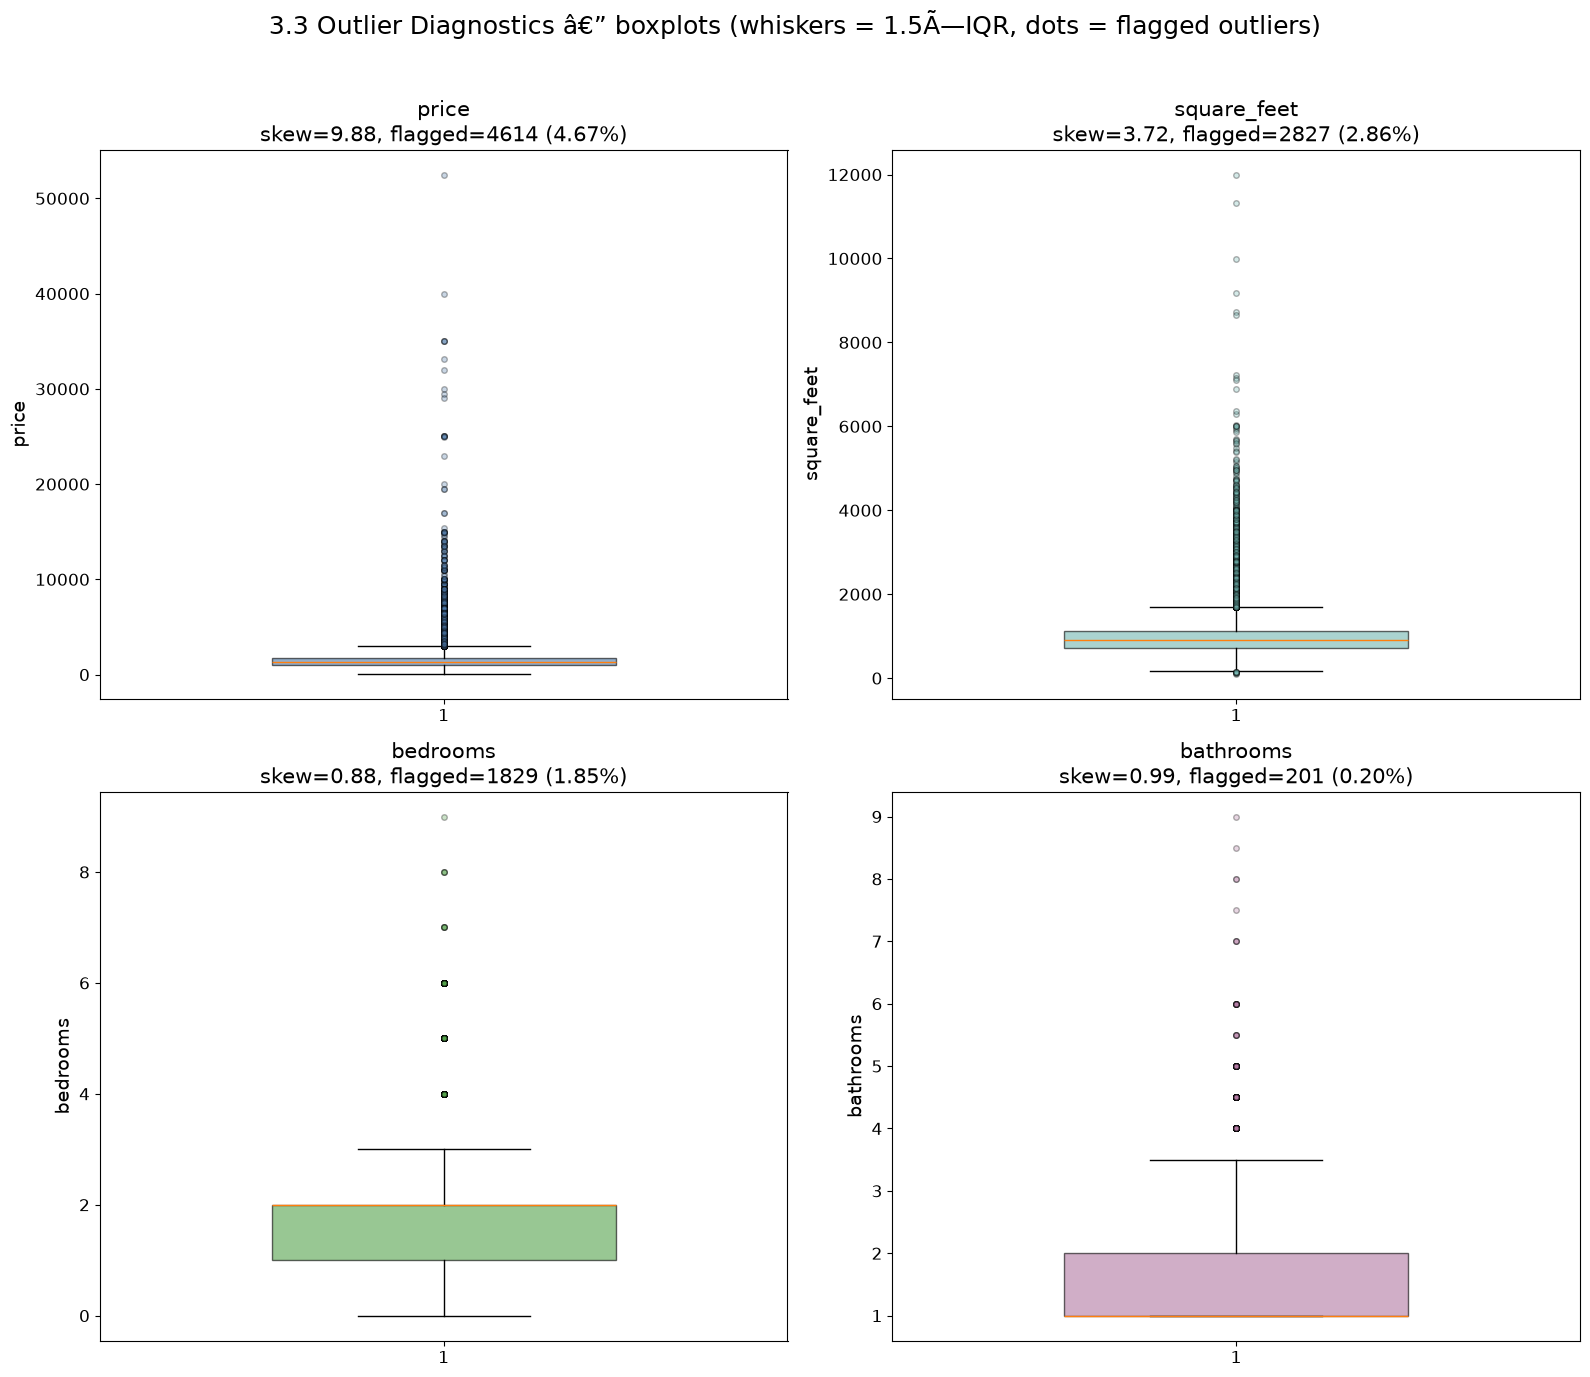

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
cols = [('price', '#4C78A8'), ('square_feet', '#72B7B2'),
        ('bedrooms', '#54A24B'), ('bathrooms', '#B279A2')]

for ax, (col, color) in zip(axes.flat, cols):
    lower, upper = compute_iqr_bounds(df_clean, col)
    skew = df_clean[col].skew()
    n_flagged = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    bp = ax.boxplot(df_clean[col], vert=True, patch_artist=True, widths=0.5,
                     flierprops={'markersize': 4, 'alpha': 0.3, 'markerfacecolor': color})
    bp['boxes'][0].set_facecolor(color)
    bp['boxes'][0].set_alpha(0.6)
    ax.set_title(f'{col}\nskew={skew:.2f}, flagged={n_flagged} ({n_flagged/len(df_clean):.2%})', fontsize=15)
    ax.set_ylabel(col, fontsize=14)
    ax.tick_params(axis='both', labelsize=12)

fig.suptitle('3.3 Outlier Diagnostics â€” boxplots (whiskers = 1.5Ã—IQR, dots = flagged outliers)', fontsize=18)
fig.tight_layout(rect=[0,0,1,0.96])
fig.savefig('../outputs/figures/33_boxplots.png', dpi=200, bbox_inches='tight')
plt.show()

In [11]:
audit_iqr(df_clean, ["price", "square_feet", "bathrooms", "bedrooms"], k=1.5)

Variable          Count      Mean        SD       Min       25%    Median       75%       Max       Lower       Upper   Flagged
-------------------------------------------------------------------------------------------------------------------------------
price             98860   1525.48    898.98    100.00   1013.00   1350.00   1795.00  52500.00     -160.00     2968.00      4614
square_feet       98860    955.99    365.31    107.00    730.00    900.00   1115.00  12000.00      152.50     1692.50      2827
bathrooms         98860      1.45      0.55      1.00      1.00      1.00      2.00      9.00       -0.50        3.50       201
bedrooms          98860      1.73      0.75      0.00      1.00      2.00      2.00      9.00       -0.50        3.50      1829


Listings above $20,000 per month are inspected and removed as implausible or outside the intended apartment-rental scope.

In [12]:
print(df_clean[df_clean["price"] > PRICE_MAX_VALID][
    ["price", "square_feet", "bedrooms", "bathrooms", "cityname"]
])
df_clean = remove_extreme_price_errors(df_clean, verbose=True)

         price  square_feet  bedrooms  bathrooms           cityname
3487   25000.0         8716       6.0        8.0          Montecito
6863   52500.0         1418       0.0        1.0            Barstow
14400  30000.0         5872       5.0        5.5   Snowmass Village
17131  35000.0         2269       4.0        4.0     West Hollywood
23574  25000.0         6881       4.0        5.0      Playa Del Rey
23888  23000.0         3280       3.0        3.5        Los Angeles
28037  35000.0         5586       7.0        5.0     West Hollywood
31279  29500.0         4291       3.0        3.0             Venice
38376  29000.0         7213       6.0        6.0      Beverly Hills
38473  32000.0         5055       6.0        9.0        Los Angeles
40715  35000.0         6366       6.0        7.5     West Hollywood
40932  40000.0         7145       6.0        8.0        Los Angeles
41199  25000.0         6035       5.0        7.0        Los Angeles
45817  33165.0         2211       3.0        2.5

In [13]:
audit_iqr(df_clean, ["price", "square_feet", "bathrooms", "bedrooms"], k=1.5)

Variable          Count      Mean        SD       Min       25%    Median       75%       Max       Lower       Upper   Flagged
-------------------------------------------------------------------------------------------------------------------------------
price             98844   1520.68    810.69    100.00   1013.00   1350.00   1795.00  20000.00     -160.00     2968.00      4598
square_feet       98844    955.32    360.64    107.00    730.00    900.00   1115.00  12000.00      152.50     1692.50      2812
bathrooms         98844      1.45      0.54      1.00      1.00      1.00      2.00      8.50       -0.50        3.50       189
bedrooms          98844      1.73      0.75      0.00      1.00      2.00      2.00      9.00       -0.50        3.50      1818


In [14]:

df_capped = winsorize(df_clean, verbose=True)

[3.3] square_feet: capped 2805 rows (2.84%) above 1,692 (IQR upper bound)


In [15]:
df_capped[["price", "square_feet"]].describe().round(2)

,price,square_feet
count,98844.00,98844.00
mean,1520.68,938.96
std,810.69,285.86
min,100.00,107.00
25%,1013.00,730.00
50%,1350.00,900.00
75%,1795.00,1115.00
max,20000.00,1692.50


## 3.4 Data Transformation
Amenity/pets multi-label engineering, room density feature, and target-encoded city.

In [16]:
city_unique = df_capped['cityname'].nunique()
print(f"Unique cityname values: {city_unique:,}")

# Show unique multi-value combinations
combination_count = df_capped['amenities'].fillna('None').nunique()
print(f"Unique amenity combinations: {combination_count:,}")

Unique cityname values: 2,974
Unique amenity combinations: 9,779


In [17]:
df_transformed = transform(df_capped)
numeric, categorical, city = get_engineered_feature_lists(df_transformed)

print('Numeric features (', len(numeric), '):', numeric)
print('Categorical features (', len(categorical), '):', categorical)
print('City feature (target-encoded):', city)

Numeric features ( 21 ): ['bathrooms', 'bedrooms', 'square_feet', 'latitude', 'longitude', 'amenity_count', 'squarefeet_per_room', 'allows_cats', 'allows_dogs', 'pets_policy_specified', 'amenity_has_parking', 'amenity_has_pool', 'amenity_has_gym', 'amenity_has_patio_deck', 'amenity_has_washer_dryer', 'amenity_has_storage', 'amenity_has_clubhouse', 'amenity_has_dishwasher', 'amenity_has_ac', 'amenity_has_fireplace', 'amenity_has_refrigerator']
Categorical features ( 2 ): ['state', 'has_photo']
City feature (target-encoded): ['cityname']


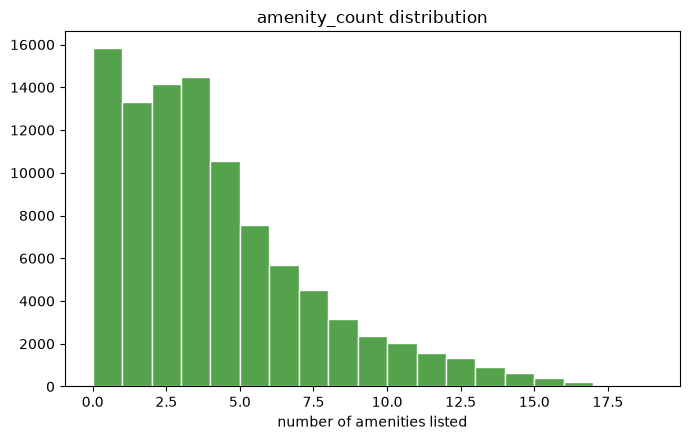

In [18]:
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.hist(df_transformed['amenity_count'], bins=range(0, 20), color='#54A24B', edgecolor='white')
ax.set_title('amenity_count distribution')
ax.set_xlabel('number of amenities listed')

fig.tight_layout()
plt.show()


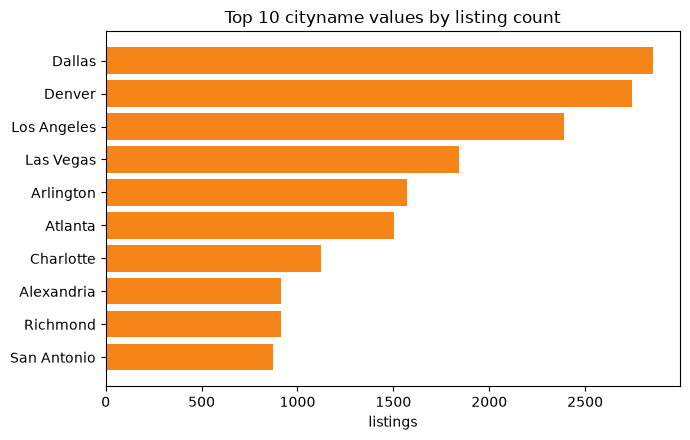

In [19]:
fig, ax = plt.subplots(figsize=(7, 4.5))

city_counts = df_transformed['cityname'].value_counts().head(10)
ax.barh(city_counts.index[::-1], city_counts.values[::-1], color='#F58518')
ax.set_title('Top 10 cityname values by listing count')
ax.set_xlabel('listings')

fig.tight_layout()
plt.show()

In [20]:
df_transformed['amenity_count'].describe().round(2)

count    98844.00
mean         3.67
std          3.30
min          0.00
25%          1.00
50%          3.00
75%          5.00
max         18.00
Name: amenity_count, dtype: float64

In [21]:
# No frequency threshold / "Other" bucket needed anymore â€” cityname is
# target-encoded (see build_preprocessor), so every city keeps its own signal
# regardless of how many listings it has.
print("Unique cities:", df_capped["cityname"].nunique())

Unique cities: 2974


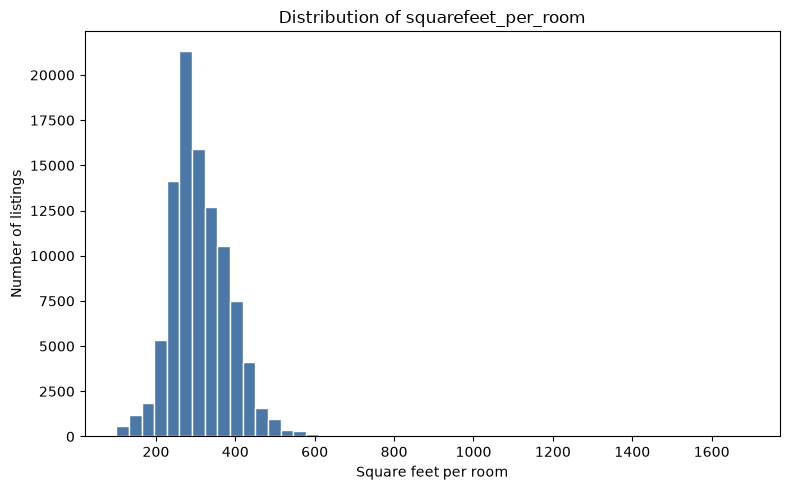

In [22]:
plt.figure(figsize=(8, 5))
plt.hist(df_transformed["squarefeet_per_room"], bins=50, color="#4C78A8", edgecolor="white")
plt.title("Distribution of squarefeet_per_room")
plt.xlabel("Square feet per room"); plt.ylabel("Number of listings")
plt.tight_layout(); plt.show()

In [23]:
print('pets_allowed split into binary flags:')
print(df_transformed[['allows_cats','allows_dogs','pets_policy_specified']].sum())

pets_allowed split into binary flags:
allows_cats              38726
allows_dogs              37020
pets_policy_specified    38852
dtype: int64


## 3.5 Final Prepared Dataset
Runs the full pipeline in the correct order (3.2 â†’ 3.3 â†’ 3.4) via `build_prepared_dataset()`, and writes the model-ready CSV.

In [24]:
prepared_df = build_prepared_dataset(
    raw_csv_path=RAW_CSV_PATH,
    verbose=True
)

prepared_df.to_csv(
    "../data/apartments_prepared.csv",
    index=False
)

prepared_df.head()

Raw shape: (99492, 22)
[3.2.1] Removed 84 duplicate listings (matched on id)
[3.2.2] Removed 65 non-standard-apartment / non-monthly rows
[3.2.3] Removed 483 rows with missing critical values

Final shape: (98860, 11)  (kept 99.4% of raw rows)
Missing values remaining:
 amenities       0
bathrooms       0
bedrooms        0
has_photo       0
pets_allowed    0
price           0
square_feet     0
cityname        0
state           0
latitude        0
longitude       0
dtype: int64
[3.3] Removed 16 listings with price > $20,000
[3.3] square_feet: capped 2805 rows (2.84%) above 1,692 (IQR upper bound)

Prepared dataset: (98844, 11)
Missing values after cleaning/outlier treatment: 0


,amenities,bathrooms,bedrooms,has_photo,pets_allowed,price,square_feet,cityname,state,latitude,longitude
0,None,1.0,1.0,Thumbnail,Cats,2195.0,542.0,Redondo Beach,CA,33.8520,-118.3759
1,None,1.5,3.0,Thumbnail,"Cats,Dogs",1250.0,1500.0,Newport News,VA,37.0867,-76.4941
2,None,2.0,3.0,Thumbnail,Not Specified,1395.0,1650.0,Raleigh,NC,35.8230,-78.6438
3,None,1.0,2.0,Thumbnail,"Cats,Dogs",1600.0,820.0,Vacaville,CA,38.3622,-121.9712
4,None,1.0,1.0,Thumbnail,"Cats,Dogs",975.0,624.0,Albuquerque,NM,35.1038,-106.6110


In [25]:
prepared_df.isna().sum().sum()

np.int64(0)

In [26]:
from sklearn.model_selection import train_test_split

# Split BEFORE any transformation
X = prepared_df.drop(columns=["price"])
y = prepared_df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

print(f"Train mean price = ${y_train.mean():.2f}")
print(f"Test  mean price = ${y_test.mean():.2f}")

Train: (79075, 10)
Test : (19769, 10)
Train mean price = $1519.23
Test  mean price = $1526.46


In [27]:
X_train_transformed = transform(X_train)
X_test_transformed = transform(X_test)

numeric, categorical, city = get_engineered_feature_lists(X_train_transformed)
print('Numeric features (', len(numeric), '):', numeric)
print('Categorical features (', len(categorical), '):', categorical)
print('City feature (target-encoded):', city)

print(X_train_transformed.shape)
print(X_test_transformed.shape)

Numeric features ( 21 ): ['bathrooms', 'bedrooms', 'square_feet', 'latitude', 'longitude', 'amenity_count', 'squarefeet_per_room', 'allows_cats', 'allows_dogs', 'pets_policy_specified', 'amenity_has_parking', 'amenity_has_pool', 'amenity_has_gym', 'amenity_has_patio_deck', 'amenity_has_washer_dryer', 'amenity_has_storage', 'amenity_has_clubhouse', 'amenity_has_dishwasher', 'amenity_has_ac', 'amenity_has_fireplace', 'amenity_has_refrigerator']
Categorical features ( 2 ): ['state', 'has_photo']
City feature (target-encoded): ['cityname']
(79075, 24)
(19769, 24)


In [28]:
preprocessor = build_preprocessor(
    numeric,
    categorical,
    city,
    scale_numeric=True
)

# TargetEncoder is supervised, so fit_transform needs y_train â€” never fit on test data.
XX_train = preprocessor.fit_transform(X_train_transformed, y_train)

XX_test = preprocessor.transform(X_test_transformed)

print("Encoded train:", XX_train.shape)
print("Encoded test :", XX_test.shape)

Encoded train: (79075, 76)
Encoded test : (19769, 76)


In [29]:
import numpy as np

# XX_train/XX_test are dense (target encoding + scaling produce dense output),
# unlike the pre-target-encoding pipeline which was sparse from one-hot alone.
print("NaN in train:", np.isnan(XX_train).any())
print("NaN in test:", np.isnan(XX_test).any())

NaN in train: False
NaN in test: False
